# Dilated Intra-Fixation Edge Explorer

Interactive notebook for inspecting **dilated intra-fixation edges**
(**razširjene povezave znotraj fiksacije**) before changing GNN v2 graph
construction.

The construction treats a fixation as a cyclic ordered run of `F` nodes. For a
chosen density parameter `kf`, it computes a dilation step `s` and connects every
node with the same set of cyclic offsets. The notebook reports `|E|`, the chosen
step `s`, node degrees, and the size of an `L`-hop neighborhood for a selected
node `v`, where `L` can be interpreted as the number of GNN layers.


## Definition

For a fixation with local nodes `0, 1, ..., F-1`:

- `F`: number of nodes in the fixation.
- `kf`: density parameter.
- `s = max(1, floor(F / kf + 0.5))`.
- `D = unique((1 + q * s) mod F for q = 0, ..., kf-1)`, with `0` removed.
- For each node `i` and each offset `d` in `D`, add an undirected edge
  `{i, (i + d) mod F}`.
- Deduplicate undirected pairs; PyG will store each undirected pair as two
  directed edges.

Offset `0` is removed because it creates a self-loop: the target node is the
same as the source node. We do not want self-loops inside the fixation relation.


In [20]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass

import math
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

plt.rcParams['figure.figsize'] = (7, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [21]:
def round_half_up(value: float) -> int:
    """Round to nearest integer with .5 rounded upward."""
    return int(math.floor(float(value) + 0.5))


def build_dilated_fixation_edges(F: int, kf: int) -> dict:
    """Build deduplicated undirected dilated intra-fixation edges.

    Returns a dictionary with the dilation step, offsets, undirected edges,
    directed edge count, and adjacency list for one fixation of length F.
    """
    if F < 1:
        raise ValueError('F must be >= 1.')
    if kf < 1:
        raise ValueError('kf must be >= 1.')

    step = max(1, round_half_up(F / kf))
    offsets = sorted({(1 + q * step) % F for q in range(kf)} - {0})

    undirected_edges: set[tuple[int, int]] = set()
    for i in range(F):
        for offset in offsets:
            j = (i + offset) % F
            if i == j:
                continue
            edge = (i, j) if i < j else (j, i)
            undirected_edges.add(edge)

    adjacency = {i: set() for i in range(F)}
    for i, j in undirected_edges:
        adjacency[i].add(j)
        adjacency[j].add(i)

    return {
        'F': F,
        'kf': kf,
        'step': step,
        'offsets': offsets,
        'undirected_edges': sorted(undirected_edges),
        'directed_edge_count': 2 * len(undirected_edges),
        'adjacency': adjacency,
    }


def l_hop_neighborhood(adjacency: dict[int, set[int]], v: int, L: int) -> set[int]:
    """Return nodes reachable from v in <= L undirected hops, including v."""
    if L < 0:
        raise ValueError('L must be >= 0.')
    seen = {v}
    queue = deque([(v, 0)])
    while queue:
        node, depth = queue.popleft()
        if depth == L:
            continue
        for neighbor in adjacency[node]:
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append((neighbor, depth + 1))
    return seen


def summarize_graph(F: int, kf: int, L: int, v: int) -> tuple[dict, pd.DataFrame]:
    """Build graph and return a compact metric table."""
    graph = build_dilated_fixation_edges(F=F, kf=kf)
    v = int(np.clip(v, 0, F - 1))
    neighborhood = l_hop_neighborhood(graph['adjacency'], v=v, L=L)
    degrees = [len(graph['adjacency'][i]) for i in range(F)]
    metrics = pd.DataFrame(
        [
            ('F', F),
            ('kf', kf),
            ('s', graph['step']),
            ('offsets D', graph['offsets']),
            ('|E| undirected', len(graph['undirected_edges'])),
            ('degree min', min(degrees) if degrees else 0),
            ('degree mean', float(np.mean(degrees)) if degrees else 0.0),
            ('degree max', max(degrees) if degrees else 0),
            ('selected v', v),
            ('L', L),
            ('|N_L(v)| incl. v', len(neighborhood)),
            ('|N_L(v)| / F', len(neighborhood) / F),
            ('N_L(v)', sorted(neighborhood)),
        ],
        columns=['metric', 'value'],
    )
    return graph, metrics


In [22]:
def plot_fixation_graph(F: int = 30, kf: int = 3, L: int = 3, v: int = 0, max_draw_edges: int = 800) -> pd.DataFrame:
    """Plot the dilated fixation graph, display metrics, and return the metric table."""
    graph, metrics = summarize_graph(F=F, kf=kf, L=L, v=v)
    v = int(np.clip(v, 0, F - 1))
    neighborhood = l_hop_neighborhood(graph['adjacency'], v=v, L=L)

    angles = np.linspace(0, 2 * np.pi, F, endpoint=False)
    xy = np.column_stack([np.cos(angles), np.sin(angles)])

    fig, ax = plt.subplots(figsize=(7, 7))
    edges = graph['undirected_edges']
    draw_edges = edges if len(edges) <= max_draw_edges else edges[:max_draw_edges]
    for i, j in draw_edges:
        color = '#2b6cb0' if i in neighborhood and j in neighborhood else '#9aa7b2'
        alpha = 0.28 if i in neighborhood and j in neighborhood else 0.12
        ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color=color, alpha=alpha, linewidth=1.8)

    node_colors = ['#d62828' if i == v else '#f6ae2d' if i in neighborhood else '#4f5d75' for i in range(F)]
    ax.scatter(xy[:, 0], xy[:, 1], s=80, c=node_colors, edgecolor='white', linewidth=1.8, zorder=3)

    if F <= 80:
        for idx, (x, y) in enumerate(xy):
            ax.text(x * 1.09, y * 1.09, str(idx), ha='center', va='center', fontsize=8)

    title = f'F={F}, kf={kf}, s={graph["step"]}, |E|={len(edges)} undirected / {graph["directed_edge_count"]} directed'
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    if len(edges) > max_draw_edges:
        ax.text(0, -1.18, f'Drawing first {max_draw_edges} of {len(edges)} edges.', ha='center', fontsize=9)
    plt.show()
    display(metrics)
    return metrics


## Static Example

The example below uses the current GNN v2 default: for `F=30` and `kf=3`,
local node `0` uses offsets `[1, 11, 21]`. The sweep later still includes
`kf=10` for comparison with the denser exploratory setting.


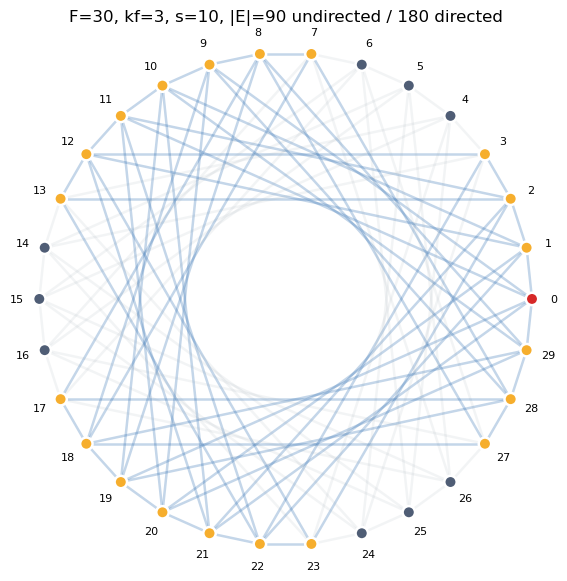

,metric,value
0,F,30
1,kf,3
2,s,10
3,offsets D,"[1, 11, 21]"
4,|E| undirected,90
5,degree min,6
6,degree mean,6.0
7,degree max,6
8,selected v,0
9,L,3


In [23]:
plot_fixation_graph(F=30, kf=3, L=3, v=0);


## Interactive Explorer

Use the sliders to inspect how `F`, `kf`, and the number of GNN layers `L`
change the graph. The selected node `v` is red; its `L`-hop neighborhood is
highlighted in yellow.


In [24]:
if HAS_WIDGETS:
    ui = widgets.interactive(
        plot_fixation_graph,
        F=widgets.IntSlider(value=30, min=2, max=50, step=1, description='F'),
        kf=widgets.IntSlider(value=3, min=1, max=10, step=1, description='kf'),
        L=widgets.IntSlider(value=3, min=0, max=10, step=1, description='L'),
        v=widgets.IntSlider(value=0, min=0, max=49, step=1, description='v'),
    )
    display(ui)
else:
    print('ipywidgets is not available in this environment. Running a static fallback instead.')
    plot_fixation_graph(F=30, kf=3, L=3, v=0)


interactive(children=(IntSlider(value=30, description='F', max=50, min=2), IntSlider(value=3, description='kf'…

## Small Sweep

This table is useful for quickly checking edge counts and neighborhood growth
for several `kf` values at a fixed `F` and `L`.


In [25]:
def sweep_kf(F: int = 60, kf_values: Iterable[int] = (2, 3, 5, 10), L: int = 3, v: int = 0) -> pd.DataFrame:
    rows = []
    for kf in kf_values:
        graph, _ = summarize_graph(F=F, kf=int(kf), L=L, v=v)
        neighborhood = l_hop_neighborhood(graph['adjacency'], v=v, L=L)
        degrees = [len(graph['adjacency'][i]) for i in range(F)]
        rows.append({
            'F': F,
            'kf': int(kf),
            's': graph['step'],
            'offsets': graph['offsets'],
            '|E| undirected': len(graph['undirected_edges']),
            '|E| directed': graph['directed_edge_count'],
            'degree_mean': float(np.mean(degrees)),
            '|N_L(v)| incl. v': len(neighborhood),
            '|N_L(v)| excl. v': max(0, len(neighborhood) - 1),
        })
    return pd.DataFrame(rows)

sweep_kf(F=60, kf_values=(2, 3, 5, 10), L=3, v=0)


,F,kf,s,offsets,|E| undirected,|E| directed,degree_mean,|N_L(v)| incl. v,|N_L(v)| excl. v
0,60,2,30,"[1, 31]",120,240,4.0,14,13
1,60,3,20,"[1, 21, 41]",180,360,6.0,21,20
2,60,5,12,"[1, 13, 25, 37, 49]",300,600,10.0,35,34
3,60,10,6,"[1, 7, 13, 19, 25, 31, 37, 43, 49, 55]",600,1200,20.0,60,59
